# Fuzzy - The Tipping Problem

Kasus ini menggunakan logika fuzzy untuk membantu pelanggan menentukan persentase tip yang direkomendasikan berdasarkan penilaian terhadap pelayanan dan rasa makanan pada sebuah restoran.

### 1. Variabel Input (Antecedent)
Terdapat dua faktor utama yang menjadi metrik penilaian pelanggan:
* **Rasa Makanan**
  * **Semesta Pembicaraan (*Universe*):** Seberapa enak rasa makanan dalam skala 0 sampai 10.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `tidak enak`, `biasa`, dan `enak`.
* **Pelayanan**
  * **Semesta Pembicaraan (*Universe*):** Seberapa baik pelayanan restoran dalam skala 0 sampai 10.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `buruk`, `biasa`, dan `baik`.

### 2. Variabel Output (Consequent)
* **Tip**
  * **Semesta Pembicaraan (*Universe*):** Persentase tip yang harus dikeluarkan dari skala 0% sampai 25%.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `sedikit`, `sedang`, dan `banyak`.

### 3. Dasar Aturan (Rule Base)
Sistem ini dieksekusi menggunakan 3 aturan logika fuzzy (IF-THEN) berikut:
1. **JIKA** rasa ENAK **DAN** pelayanan BAIK, **MAKA** tip BANYAK.
2. **JIKA** pelayanan biasa, **MAKA** tip SEDANG.
3. **JIKA** rasa BURUK **ATAU** pelayanan BURUK, **MAKA** tip SEDIKIT.

In [6]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Rentang (Universe)

In [7]:
# Antecedent (Input)
rasa = ctrl.Antecedent(np.arange(0, 11, 1), 'rasa')
pelayanan = ctrl.Antecedent(np.arange(0, 11, 1), 'pelayanan')

# Consequent (Output)
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

## Himpunan Fuzzy & Fungsi Keanggotaan

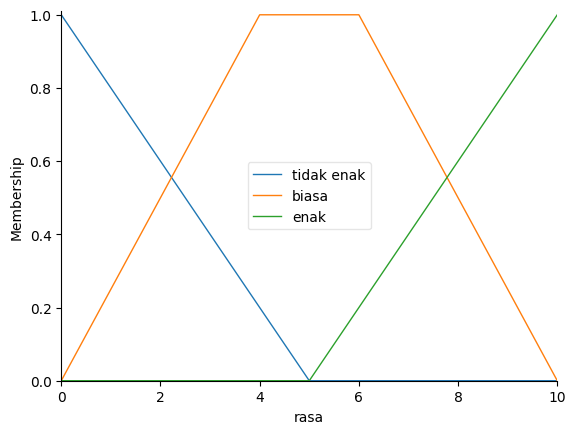

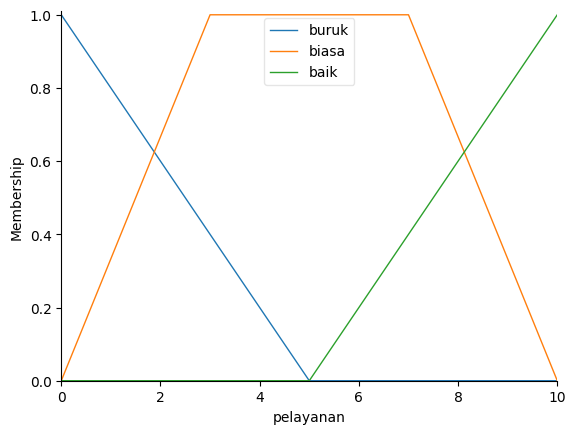

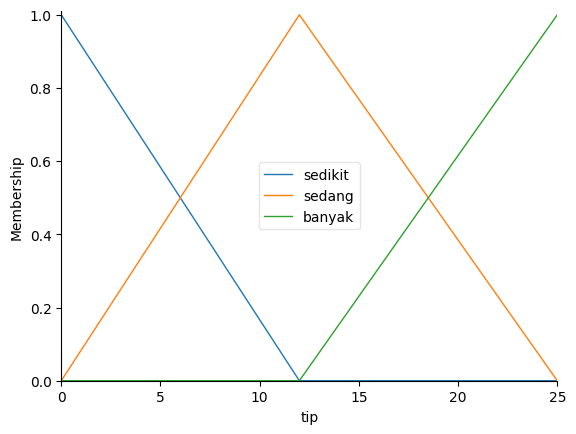

In [8]:
# Fungsi Keanggotaan untuk Rasa
rasa['tidak enak'] = fuzz.trimf(rasa.universe, [0, 0, 5])
rasa['biasa'] = fuzz.trapmf(rasa.universe, [0, 4, 6, 10])
rasa['enak'] = fuzz.trimf(rasa.universe, [5, 10, 10])

# Fungsi Keanggotaan untuk Pelayanan
pelayanan['buruk'] = fuzz.trimf(pelayanan.universe, [0, 0, 5])
pelayanan['biasa'] = fuzz.trapmf(pelayanan.universe, [0, 3, 7, 10])
pelayanan['baik'] = fuzz.trimf(pelayanan.universe, [5, 10, 10])

# Fungsi Keanggotaan untuk Tip
tip['sedikit'] = fuzz.trimf(tip.universe, [0, 0, 12])
tip['sedang'] = fuzz.trimf(tip.universe, [0, 12, 25])
tip['banyak'] = fuzz.trimf(tip.universe, [12, 25, 25])

# Visualisasi fungsi keanggotaan
rasa.view()
pelayanan.view()
tip.view()

## Rule Base

In [9]:
# Contoh sederhana
rules = [
    # tip sedikit
    ctrl.Rule(rasa['tidak enak'] | pelayanan['buruk'], tip['sedikit']),
    
    # tip sedang
    ctrl.Rule(rasa['biasa'] & pelayanan['biasa'], tip['sedang']),
    ctrl.Rule(rasa['enak'] & pelayanan['biasa'], tip['sedang']),
    
    # tip banyak
    ctrl.Rule(rasa['biasa'] & pelayanan['baik'], tip['banyak']),
    ctrl.Rule(rasa['enak'] & pelayanan['baik'], tip['banyak'])
]

# Contoh lengkap
# rules = [
#     ctrl.Rule(rasa['tidak enak'] & pelayanan['buruk'], tip['sedikit']),
#     ctrl.Rule(rasa['tidak enak'] & pelayanan['biasa'], tip['sedikit']),
#     ctrl.Rule(rasa['tidak enak'] & pelayanan['baik'], tip['sedang']),
    
#     ctrl.Rule(rasa['biasa'] & pelayanan['buruk'], tip['sedikit']),
#     ctrl.Rule(rasa['biasa'] & pelayanan['biasa'], tip['sedang']),
#     ctrl.Rule(rasa['biasa'] & pelayanan['baik'], tip['banyak']),
    
#     ctrl.Rule(rasa['enak'] & pelayanan['buruk'], tip['sedang']),
#     ctrl.Rule(rasa['enak'] & pelayanan['biasa'], tip['banyak']),
#     ctrl.Rule(rasa['enak'] & pelayanan['baik'], tip['banyak'])
# ]

# Menggabungkan aturan ke dalam sistem kontrol
tipping_ctrl = ctrl.ControlSystem(rules)
tipping_sim = ctrl.ControlSystemSimulation(tipping_ctrl)

## Defuzzifikasi

Hasil Tip: 14.12%


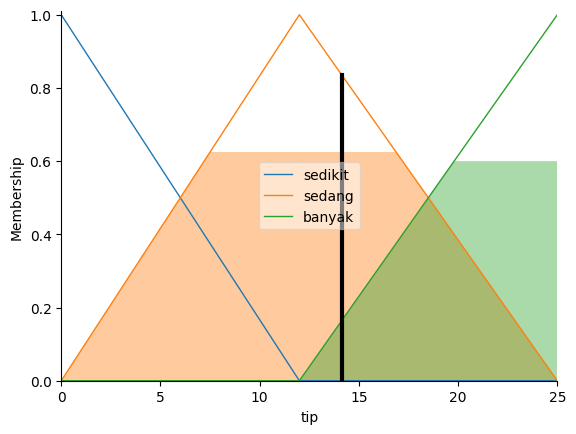

In [10]:
# Masukkan nilai input contoh
tipping_sim.input['rasa'] = 7.5
tipping_sim.input['pelayanan'] = 8.0

# Melakukan komputasi/perhitungan fuzzy
tipping_sim.compute()

# Menampilkan hasil defuzzifikasi
print(f"Hasil Tip: {tipping_sim.output['tip']:.2f}%")

# Visualisasi hasil pada kurva output
tip.view(sim=tipping_sim)